In [1]:
IMAGE_DIR = r"C:\dhruv_seminar\data\training\kaggle\working\tusimple_preprocessed\training\frames"
MASK_DIR  = r"C:\dhruv_seminar\data\training\kaggle\working\tusimple_preprocessed\training\lane-masks"

In [2]:
import os

image_paths = sorted([
    os.path.join(IMAGE_DIR, f)
    for f in os.listdir(IMAGE_DIR)
    if f.endswith(('.jpg', '.png'))
])

mask_paths = sorted([
    os.path.join(MASK_DIR, f)
    for f in os.listdir(MASK_DIR)
    if f.endswith(('.jpg', '.png'))
])

print(len(image_paths), len(mask_paths))

3626 3626


In [3]:
import sys
!{sys.executable} -m pip install opencv-python
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class LaneDataset(Dataset):
    def __init__(self, imgs, masks):
        self.imgs = imgs
        self.masks = masks

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx], 0)

        img = cv2.resize(img, (512, 256))
        mask = cv2.resize(mask, (512, 256))

        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))

        mask = (mask > 0).astype(np.float32)

        return torch.tensor(img, dtype=torch.float32), \
               torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# Step 1: 80% train, 20% temp
train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

# Step 2: split temp → 10% val, 10% test
val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs, temp_masks, test_size=0.5, random_state=42
)

# Datasets
train_dataset = LaneDataset(train_imgs, train_masks)
val_dataset   = LaneDataset(val_imgs, val_masks)
test_dataset  = LaneDataset(test_imgs, test_masks)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [5]:
import sys
!{sys.executable} -m pip install segmentation-models-pytorch

In [6]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_model(encoder):
    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1
    )
    return model.to(device)

models_dict = {
    "resnet50": get_model("resnet50"),
    "resnet101": get_model("resnet101"),
    "vgg16": get_model("vgg16"),
    "mobilenet": get_model("mobilenet_v2"),
    "efficientnet": get_model("efficientnet-b0")
}

D:\Vansh\torch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
dice = smp.losses.DiceLoss(mode='binary')
bce  = torch.nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return dice(pred, target) + bce(pred, target)

In [8]:
def train_model(model, train_loader, val_loader, epochs=100, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- Validation ----
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, masks)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # ---- Early stopping logic (no saving here) ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered!")
            break


    return model

In [9]:
for name, model in models_dict.items():
    print(f"\nTraining {name}...")

    model = train_model(model, train_loader, val_loader, epochs=100)

    torch.save(model.state_dict(), f"{name}_final.pth")

    del model
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()


Training resnet50...
Epoch 1, Train Loss: 0.6235, Val Loss: 0.4119
Epoch 2, Train Loss: 0.3373, Val Loss: 0.3642
Epoch 3, Train Loss: 0.3132, Val Loss: 0.3332
Epoch 4, Train Loss: 0.3024, Val Loss: 0.3163
Epoch 5, Train Loss: 0.2928, Val Loss: 0.3131
Epoch 6, Train Loss: 0.2858, Val Loss: 0.3357
Epoch 7, Train Loss: 0.2827, Val Loss: 0.3060
Epoch 8, Train Loss: 0.2737, Val Loss: 0.3030
Epoch 9, Train Loss: 0.2685, Val Loss: 0.3591
Epoch 10, Train Loss: 0.2627, Val Loss: 0.3052
Epoch 11, Train Loss: 0.2574, Val Loss: 0.3014
Epoch 12, Train Loss: 0.2503, Val Loss: 0.3128
Epoch 13, Train Loss: 0.2439, Val Loss: 0.3125
Epoch 14, Train Loss: 0.2394, Val Loss: 0.3173
Epoch 15, Train Loss: 0.2288, Val Loss: 0.3147
Epoch 16, Train Loss: 0.2239, Val Loss: 0.3344
Epoch 17, Train Loss: 0.2213, Val Loss: 0.3140
Epoch 18, Train Loss: 0.2128, Val Loss: 0.3115
Epoch 19, Train Loss: 0.2035, Val Loss: 0.3082
Epoch 20, Train Loss: 0.1971, Val Loss: 0.3157
Epoch 21, Train Loss: 0.1934, Val Loss: 0.3154


In [15]:
def dice_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)


def accuracy_score(pred, target):
    pred = (pred > 0.5).float()
    correct = (pred == target).float().sum()
    return correct / target.numel()
def iou_score(pred, target):
    pred = (pred > 0.5).float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    return (intersection + 1e-6) / (union + 1e-6)



def rmse_score(pred, target):
    return torch.sqrt(((pred - target) ** 2).mean())


# 🔍 EVALUATE ALL MODELS
for name, model in trained_models.items():
    model.eval()

    total_iou = 0
    total_dice = 0
    total_acc = 0
    total_rmse = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)

            total_iou += iou_score(preds, masks).item()
            total_dice += dice_score(preds, masks).item()
            total_acc += accuracy_score(preds, masks).item()
            total_rmse += rmse_score(preds, masks).item()

    n = len(val_loader)

    print(f"\n{name}")
    print(f"IoU: {total_iou/n:.4f}")
    print(f"Dice: {total_dice/n:.4f}")
    print(f"Accuracy: {total_acc/n:.4f}")
    print(f"RMSE: {total_rmse/n:.4f}")


resnet50
IoU: 0.6425
Dice: 0.7822
Accuracy: 0.9756
RMSE: 12.0083

resnet101
IoU: 0.6371
Dice: 0.7781
Accuracy: 0.9752
RMSE: 12.2115

vgg16
IoU: 0.6541
Dice: 0.7907
Accuracy: 0.9765
RMSE: 11.3173

mobilenet
IoU: 0.6506
Dice: 0.7881
Accuracy: 0.9763
RMSE: 11.2137

efficientnet
IoU: 0.6548
Dice: 0.7912
Accuracy: 0.9768
RMSE: 11.2175


In [16]:
trained_models = models_dict
print(trained_models.keys())
model_list = list(trained_models.values())
model_names = list(trained_models.keys())

print(model_names)

dict_keys(['resnet50', 'resnet101', 'vgg16', 'mobilenet', 'efficientnet'])
['resnet50', 'resnet101', 'vgg16', 'mobilenet', 'efficientnet']


In [17]:
import numpy as np
import torch

model_list = list(trained_models.values())
model_names = list(trained_models.keys())

# Thompson Sampling variables
rewards = np.ones(len(model_list))
counts  = np.ones(len(model_list))

selection_history = []

def select_model(rewards, counts):
    samples = [
        np.random.beta(rewards[i], counts[i])
        for i in range(len(rewards))
    ]
    return np.argmax(samples)


# MAB Evaluation Loop
for imgs, masks in val_loader:   # or test_loader (depending on paper)
    imgs = imgs.to(device)
    masks = masks.to(device)

    # Step 1: select model
    idx = select_model(rewards, counts)
    model = model_list[idx]

    model.eval()
    with torch.no_grad():
        preds = model(imgs)

        # IMPORTANT: ensure IoU is correct implementation
        score = iou_score(preds, masks).item()

    # Step 2: Bayesian reward update (correct form)
    rewards[idx] += score
    counts[idx] += 1

    selection_history.append(idx)


# Final statistics
print("Final Rewards:", rewards)
print("Final Counts:", counts)
print("Most selected model:", model_names[np.argmax(rewards)])

Final Rewards: [4.21676242 3.59113812 4.20581031 3.52319211 4.35550177]
Final Counts: [6. 5. 6. 5. 6.]
Most selected model: efficientnet


In [20]:
import sys
!{sys.executable} -m pip install matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 322.8 kB/s eta 0:00:24
   -- ------------------------------------- 0.5/8.1 MB 322.8 kB/s eta 0:00:24
   -- ------------------------------------- 0.5/8.1 MB 322.8 kB/s eta 0:00:24
   --- ------------------------------------ 0.8/8.1 MB 338.9 kB/s eta 0:00:22
   

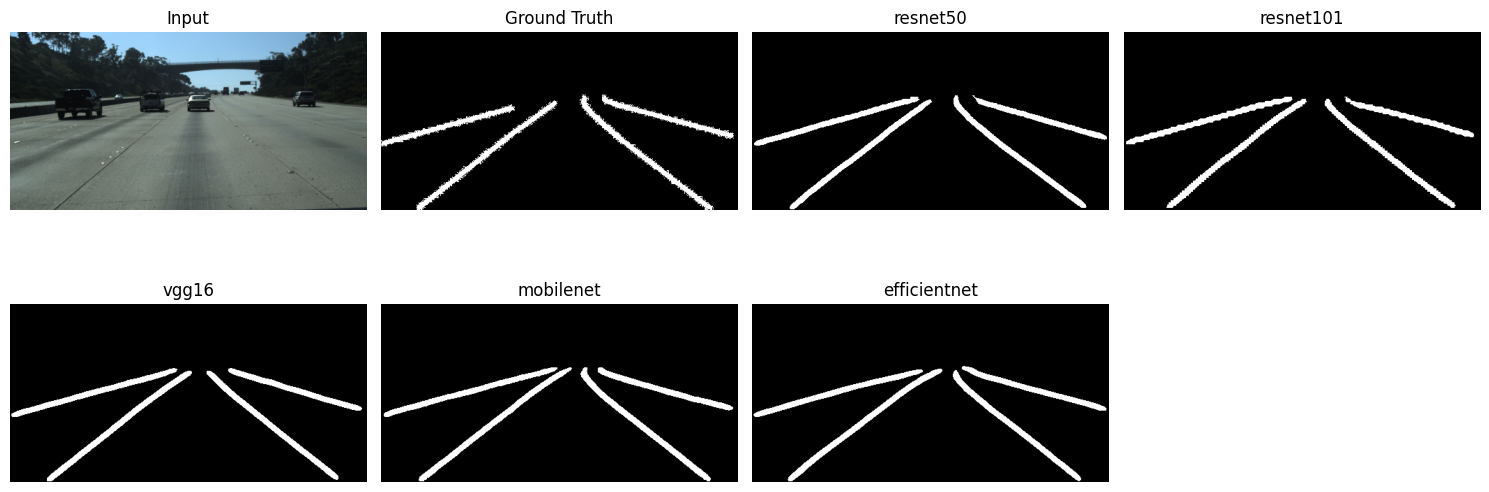

In [21]:
import matplotlib.pyplot as plt
import torch

imgs, masks = next(iter(val_loader))

imgs = imgs.to(device)
masks = masks.to(device)

plt.figure(figsize=(15, 6))

# ---- Input image ----
img = imgs[0].cpu().numpy().transpose(1, 2, 0)
mask = masks[0][0].cpu().numpy()

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title("Input")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

# ---- Model predictions ----
model_list = list(trained_models.items())

for i, (name, model) in enumerate(model_list):
    model.eval()
    with torch.no_grad():
        pred = model(imgs)

        # 🔥 IMPORTANT: apply sigmoid
        pred = torch.sigmoid(pred)

        pred = pred[0][0].cpu().numpy()
        pred = (pred > 0.5).astype(float)

    plt.subplot(2, 4, i + 3)
    plt.imshow(pred, cmap='gray')
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

for name, val_losses in all_val_losses.items():
    # Convert to numpy
    val_losses = np.array(val_losses)

    # ---- Optional smoothing (moving average) ----
    smooth = np.convolve(val_losses, np.ones(5)/5, mode='valid')

    # Adjust x-axis after smoothing
    epochs = np.arange(len(smooth))

    plt.plot(epochs, smooth, label=name, linewidth=2)

# ---- Labels & Title ----
plt.title("Validation Loss Over Epochs", fontsize=16, fontweight='bold')
plt.xlabel("Training Epochs", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)

# ---- Legend ----
plt.legend()

# ---- Grid ----
plt.grid(alpha=0.3)

# ---- Layout ----
plt.tight_layout()

plt.show()

NameError: name 'all_val_losses' is not defined

<Figure size 1000x600 with 0 Axes>